# Exploratory analysis of dataset

This notebook holds some code for an exploratory analysis of the training data from the H to Z(ll) + a (hadronic) signal process.

We first download a preprocessed file which contains information about jets and their particle flow object content.

In [3]:
import subprocess, h5py, os

url = "https://pgadow.web.cern.ch/pgadow/share/pheno/hza_ml/train.h5"
out = "train.h5"

if not os.path.exists(out):
    subprocess.run(["wget", "-O", out, url], check=True)


In [6]:
import numpy as np

# display the content of the file
with h5py.File(out, "r") as f:
    def print_keys(name, obj):
        print(name)
    f.visititems(print_keys)

# explore what is in jets and tracks
with h5py.File(out, "r") as f:
    jets = f["jets"]
    tracks = f["tracks"]
    labels = f["labels"]
    print("Jets shape:", jets.shape)
    print("Tracks shape:", tracks.shape)
    print("Labels shape:", labels.shape, "| dtype:", labels.dtype)
    print("Jets variables:", jets.dtype.names)
    print("Tracks variables:", tracks.dtype.names)
    print("Jets dtype:", jets.dtype)
    print("Tracks dtype:", tracks.dtype)


jets
labels
tracks
Jets shape: (324138,)
Tracks shape: (324138, 40)
Labels shape: (324138,) | dtype: [('a_jet', '<i4')]
Jets variables: ('pt', 'eta', 'phi', 'mass', 'a_jet')
Tracks variables: ('pt', 'eta_rel', 'phi_rel', 'mass', 'charge', 'pdgId', 'dxy', 'dz', 'dxySig', 'dzSig', 'trkQuality', 'puppiWeight', 'valid')
Jets dtype: [('pt', '<f4'), ('eta', '<f4'), ('phi', '<f4'), ('mass', '<f4'), ('a_jet', '<i4')]
Tracks dtype: [('pt', '<f4'), ('eta_rel', '<f4'), ('phi_rel', '<f4'), ('mass', '<f4'), ('charge', 'i1'), ('pdgId', '<i4'), ('dxy', '<f4'), ('dz', '<f4'), ('dxySig', '<f4'), ('dzSig', '<f4'), ('trkQuality', 'i1'), ('puppiWeight', '<f4'), ('valid', '?')]


## Check jet variables

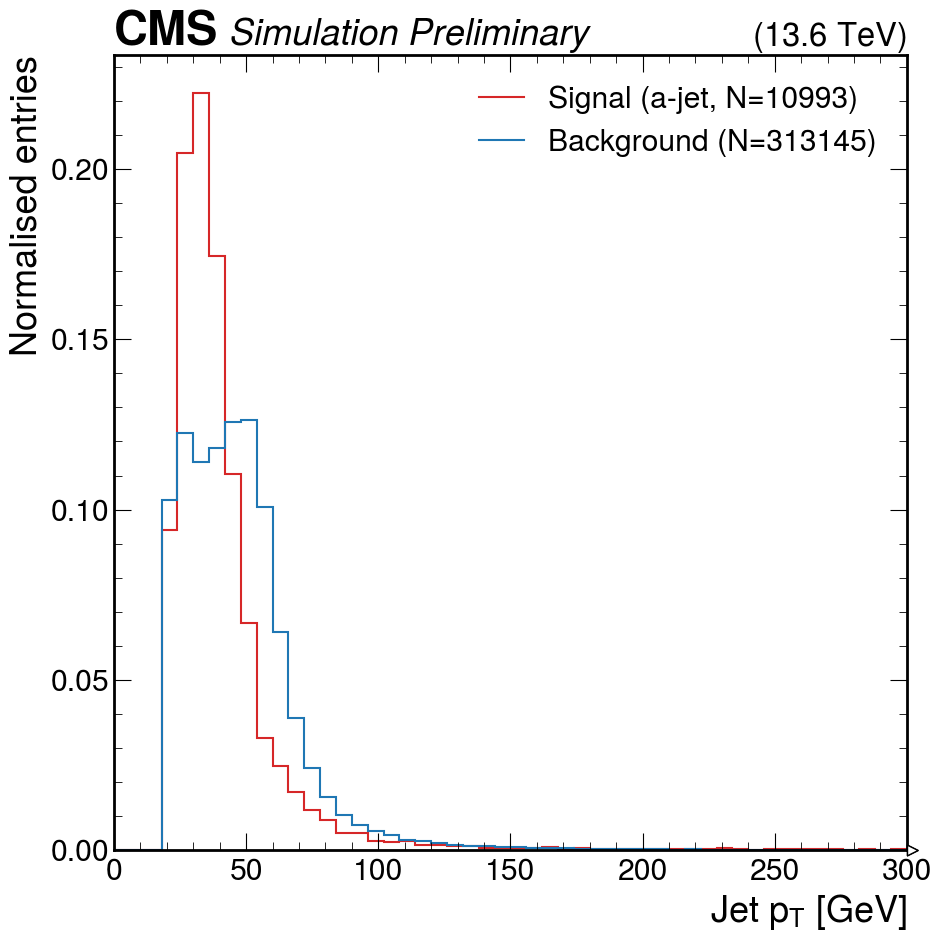

In [11]:
import matplotlib.pyplot as plt
import mplhep as hep
import hist

hep.style.use("CMS")

with h5py.File(out, "r") as f:
    jets_pt = f["jets"]["pt"][:]
    labels  = f["labels"]["a_jet"][:]   # 1 = signal (a-jet), 0 = background

sig_pt = jets_pt[labels == 1]
bkg_pt = jets_pt[labels == 0]

h_sig = hist.Hist(hist.axis.Regular(50, 0, 300, label="Jet $p_T$ [GeV]"))
h_bkg = hist.Hist(hist.axis.Regular(50, 0, 300, label="Jet $p_T$ [GeV]"))
h_sig.fill(sig_pt)
h_bkg.fill(bkg_pt)

# normalise to unit area
h_sig_norm = h_sig / h_sig.sum()
h_bkg_norm = h_bkg / h_bkg.sum()

fig, ax = plt.subplots()
hep.histplot(h_sig_norm, ax=ax, label=f"Signal (a-jet, N={len(sig_pt)})", color="tab:red")
hep.histplot(h_bkg_norm, ax=ax, label=f"Background (N={len(bkg_pt)})", color="tab:blue")
ax.set_xlabel("Jet $p_T$ [GeV]")
ax.set_xlim(0, 300)
ax.set_ylabel("Normalised entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()


In [ ]:
# here you can make plots of other jet variables

## Check track variables

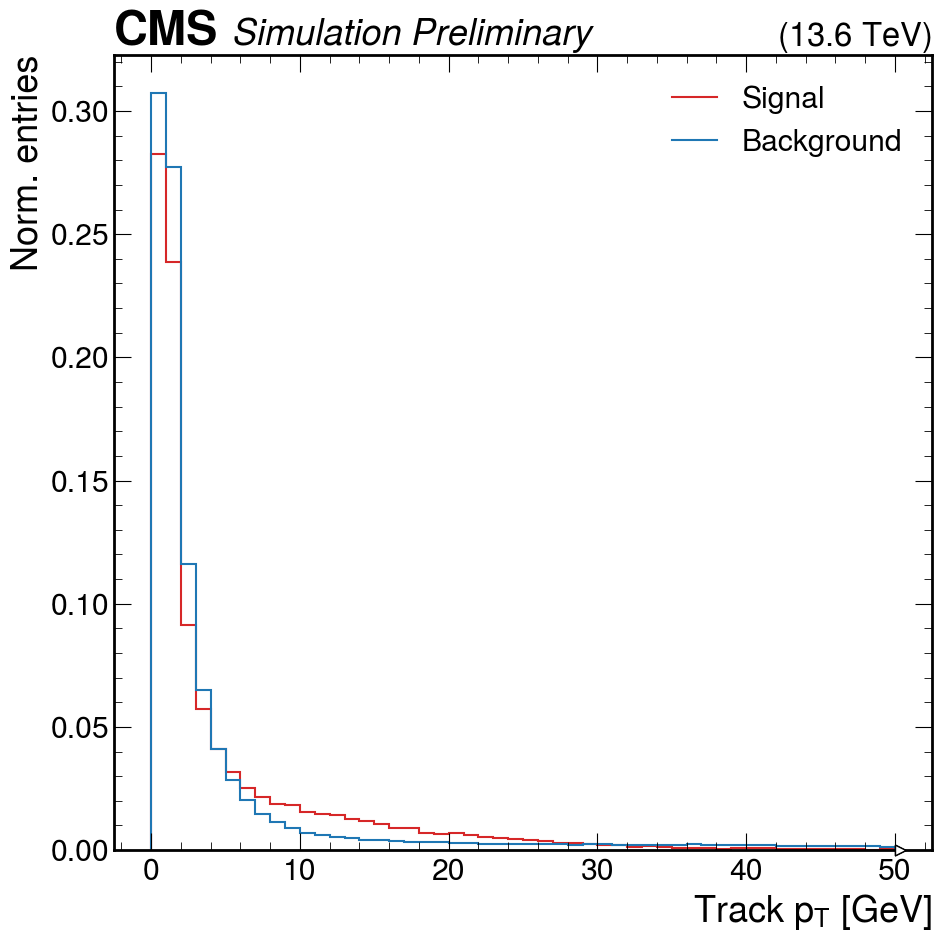

In [13]:
N_EVENTS = 50_000  # read a subset for speed

with h5py.File(out, "r") as f:
    trk = f["tracks"][:N_EVENTS]
    lbl = f["labels"]["a_jet"][:N_EVENTS]

valid_mask = trk["valid"].ravel()
lbl_flat   = np.repeat(lbl, trk.shape[1])

sig_mask = valid_mask & (lbl_flat == 1)
bkg_mask = valid_mask & (lbl_flat == 0)

trk_pt = trk["pt"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(50, 0, 50, label="Track $p_T$ [GeV]"))
h_b = hist.Hist(hist.axis.Regular(50, 0, 50, label="Track $p_T$ [GeV]"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue")
ax.set_xlabel("Track $p_T$ [GeV]")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()


In [ ]:
# here you can make plots of other track variables